# Fazendo o PCA antes de aplicar todos os métodos de regressão.

    - aplicamos o PCA para explorar a estrutura do nosso dataset. O objetivo principal foi reduzir a dimensionalidade das 11 métricas da NBA, e remover possíveis colinearidades.

Importamos os dados de treino que foram normalizados e salvos no notebook anterior. É essencial trabalhar com os dados já escalonados pelo StandardScaler, pois o PCA é extremamente sensível à escala das variáveis. Como o PCA deve ser aplicado apenas em variáveis numéricas contínuas, isolamos os identificadores (TEAM_ID e SEASON_ID) para que não interfiram na análise. Também extraímos a variável alvo (PLAYOFF_WINS) para os vetores de destino.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# carregando os datasets exportados anteriormente
X_train = pd.read_csv('../CSVs/X_train_final.csv')
y_train = pd.read_csv('../CSVs/y_train_final.csv')

X_test = pd.read_csv('../CSVs/X_test_final.csv')
y_test = pd.read_csv('../CSVs/y_test_final.csv')

# verificação (Dimensões)
print(f"--- Dimensões dos Dados ---")
print(f"Treino: X = {X_train.shape}, y = {y_train.shape}")
print(f"Teste:  X = {X_test.shape}, y = {y_test.shape}")

# preparação para o PCA e Modelos (Isolando os IDs)
# lembrando que TEAM_ID e SEASON_ID não podem entrar no treinamento
colunas_id = ['TEAM_ID', 'SEASON_ID']

# criando versões puramente numéricas para o algoritmo
X_train_features = X_train.drop(columns=colunas_id)
X_test_features = X_test.drop(columns=colunas_id)

# extraindo o vetor alvo como Series para o Scikit-Learn
y_train_target = y_train['PLAYOFF_WINS']
y_test_target = y_test['PLAYOFF_WINS']

print(f"\nFeatures prontas para o PCA: {X_train_features.columns.tolist()}")

--- Dimensões dos Dados ---
Treino: X = (802, 13), y = (802, 1)
Teste:  X = (30, 13), y = (30, 1)

Features prontas para o PCA: ['W_PCT', 'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'AST_TO', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'TM_TOV_PCT', 'TS_PCT', 'PACE']


Foi implementado o PCA para apenas 2 componentes, para focarmos na visualização em um gráfico 2D.

Variância Total Explicada (2D): 71.80%


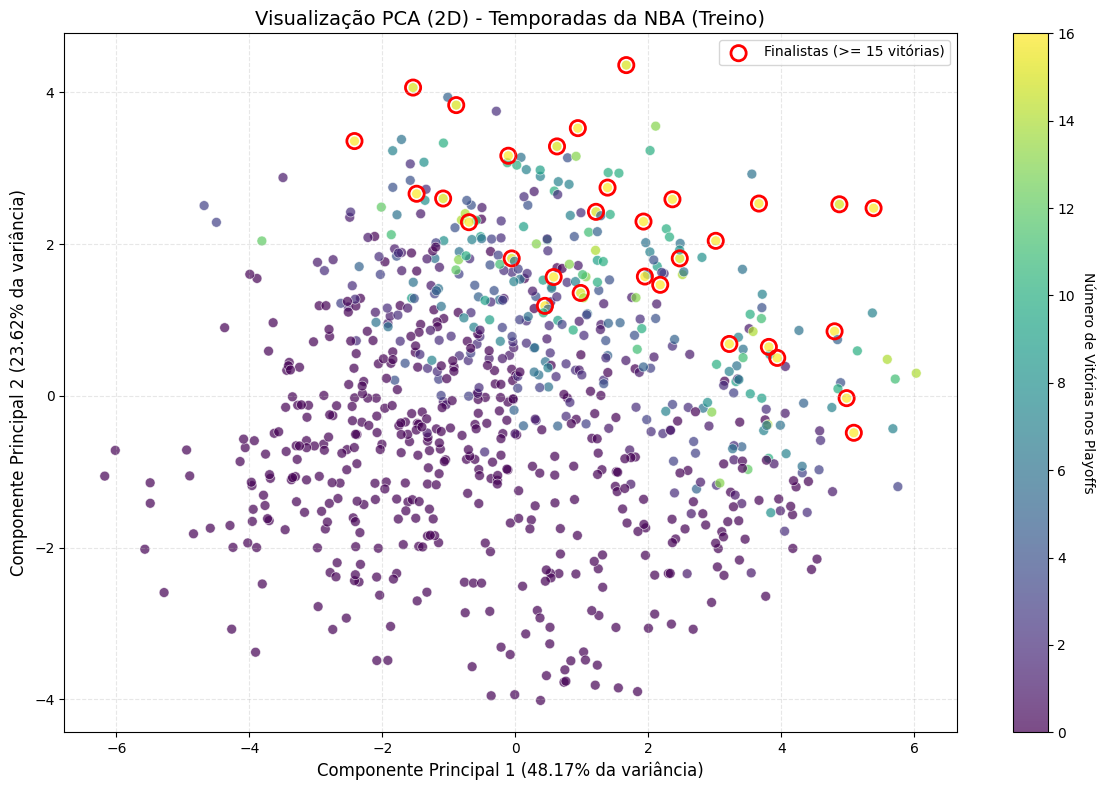

In [ ]:
from sklearn.decomposition import PCA

# executando o PCA para 2 componentes (foco em visualização)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_features)

# organizando os dados para o plot
df_pca_2d = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca_2d['PLAYOFF_WINS'] = y_train_target.values

# calculando a variância explicada para o título dos eixos
var_pc1 = pca_2d.explained_variance_ratio_[0] * 100
var_pc2 = pca_2d.explained_variance_ratio_[1] * 100

# gerando o gráfico
plt.figure(figsize=(12, 8))

# criando o scatter plot. Usamos um colormap (viridis) para representar o número de vitórias
scatter = plt.scatter(df_pca_2d['PC1'], df_pca_2d['PC2'], 
                      c=df_pca_2d['PLAYOFF_WINS'], 
                      cmap='viridis', 
                      alpha=0.7, 
                      edgecolors='w', 
                      linewidth=0.5,
                      s=50) # Tamanho dos pontos

# adicionando a barra de cores (legenda da cor)
cbar = plt.colorbar(scatter)
cbar.set_label('Número de Vitórias nos Playoffs', rotation=270, labelpad=15)

# títulos e labels explicativos
plt.title('Visualização PCA (2D) - Temporadas da NBA (Treino)', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({var_pc1:.2f}% da variância)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({var_pc2:.2f}% da variância)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)

# destacando a Elite (Campeões e Finalistas)
# vamos circular de vermelho quem teve 15 ou 16 vitórias para ver onde eles caem no gráfico
champions = df_pca_2d[df_pca_2d['PLAYOFF_WINS'] >= 15]
plt.scatter(champions['PC1'], champions['PC2'], 
            facecolors='none', 
            edgecolors='red', 
            s=120, 
            linewidth=2, 
            label='Finalistas (>= 15 vitórias)')

plt.legend()
plt.tight_layout()

print(f"Variância Total Explicada (2D): {(var_pc1 + var_pc2):.2f}%")
plt.show()

Aqui, analisamos a Variância Total Explicada para verificar o quanto de informação original foi preservada após a redução, pra cada quantidade de componentes. E, usamos isso, como critério pra escolha da quantidade.

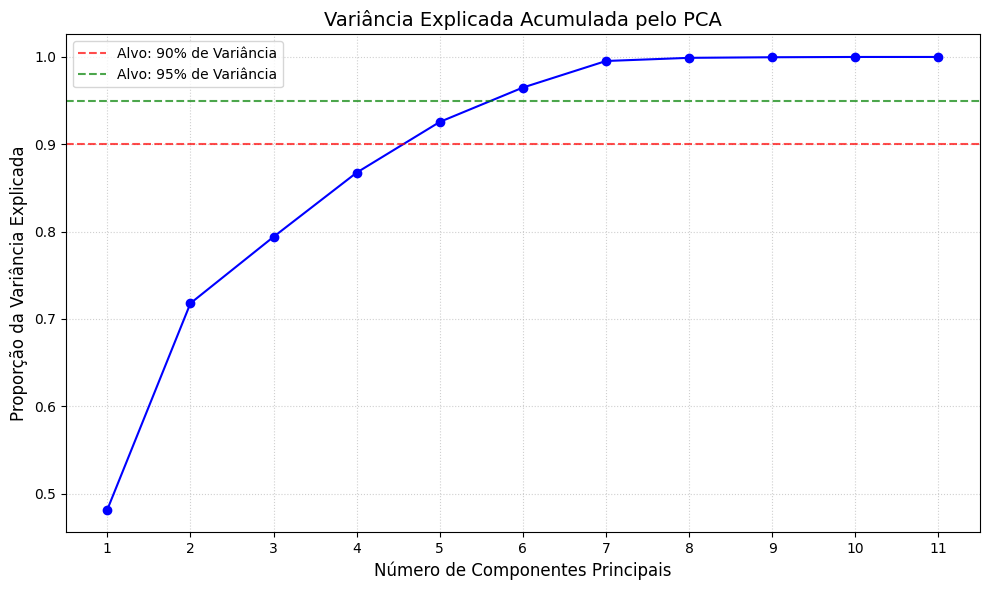

--- Evolução da Variância Explicada ---
Com 1 componentes: 48.17%
Com 2 componentes: 71.80%
Com 3 componentes: 79.40%
Com 4 componentes: 86.76%
Com 5 componentes: 92.56%
Com 6 componentes: 96.50%
Com 7 componentes: 99.54%
Com 8 componentes: 99.90%
Com 9 componentes: 99.97%
Com 10 componentes: 100.00%
Com 11 componentes: 100.00%


In [ ]:

# executando o PCA completo (com todas as features disponíveis)
pca_full = PCA()
pca_full.fit(X_train_features)

# calculando a variância explicada acumulada
variancia_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# gerar o gráfico de decisão (Scree Plot)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker='o', linestyle='-', color='b')

# adicionando linhas de referência para 90% e 95%
plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.7, label='Alvo: 90% de Variância')
plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.7, label='Alvo: 95% de Variância')

plt.title('Variância Explicada Acumulada pelo PCA', fontsize=14)
plt.xlabel('Número de Componentes Principais', fontsize=12)
plt.ylabel('Proporção da Variância Explicada', fontsize=12)
plt.xticks(range(1, len(variancia_acumulada) + 1))
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

# imprimindo os valores exatos para documentação do projeto
print("--- Evolução da Variância Explicada ---")
for i, var in enumerate(variancia_acumulada):
    print(f"Com {i+1} componentes: {var*100:.2f}%")

Fazendo a decisão, baseando-se na celula anterior.
- critério de estar entre 90 e 95 porcento, e havendo uma redução consideravel da quantidade de variáveis(11 --> 5).

In [ ]:

# definindo o número escolhido baseado na nossa análise de variância
NUM_COMPONENTES = 5 

print(f"Aplicando PCA para {NUM_COMPONENTES} componentes...")

# inicializando o PCA com o número escolhido
pca_ml = PCA(n_components=NUM_COMPONENTES)

# Fit apenas no Treino (Regra de Ouro para evitar vazamento de dados)
X_train_pca_array = pca_ml.fit_transform(X_train_features)

# Transform no Teste (Usando a mesma 'régua' aprendida no treino)
X_test_pca_array = pca_ml.transform(X_test_features)

# transformar de volta em DataFrames para facilitar o uso no Scikit-Learn
# nomeando as colunas como PC1, PC2, etc.
colunas_pca = [f'PC{i+1}' for i in range(NUM_COMPONENTES)]

X_train_pca = pd.DataFrame(X_train_pca_array, columns=colunas_pca)
X_test_pca = pd.DataFrame(X_test_pca_array, columns=colunas_pca)

print(f"Dimensões originais: {X_train_features.shape}")
print(f"Novas dimensões (PCA): {X_train_pca.shape}")
print(f"Variância retida: {sum(pca_ml.explained_variance_ratio_) * 100:.2f}%")

# agora X_train_pca e y_train_target estão prontos para o XGBoost, Random Forest, etc!

Aplicando PCA para 5 componentes...
Dimensões originais: (802, 11)
Novas dimensões (PCA): (802, 5)
Variância retida: 92.56%


Salvando o resultado final, antes de aplicar as técnicas de regressão.

In [ ]:

# recuperando os identificadores dos DataFrames que carregamos no início 
identificadores_treino = X_train[['TEAM_ID', 'SEASON_ID']].reset_index(drop=True)
identificadores_teste = X_test[['TEAM_ID', 'SEASON_ID']].reset_index(drop=True)

# juntando os IDs com as novas matrizes reduzidas pelo PCA
X_train_pca_final = pd.concat([identificadores_treino, X_train_pca], axis=1)
X_test_pca_final = pd.concat([identificadores_teste, X_test_pca], axis=1)

# salvando os novos datasets
X_train_pca_final.to_csv('../CSVs/X_train_pca.csv', index=False)
X_test_pca_final.to_csv('../CSVs/X_test_pca.csv', index=False)

print("Checkpoints do PCA criados com sucesso!")
print(f"Colunas salvas no treino: {X_train_pca_final.columns.tolist()}")

Checkpoints do PCA criados com sucesso!
Colunas salvas no treino: ['TEAM_ID', 'SEASON_ID', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5']
